# Load and visualize models

In [1]:
# HIDE CODE


import os, sys
sys.path.insert(0, '/home/hadi/Dropbox/git/IterativeVAE')
# sys.path.insert(0, '.')
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

from base.utils_model import load_model_lite

root = 'Dropbox/git/IterativeVAE'  # base directory for the project (update to match yours)
root = add_home(f"{root}/checkpoints/")  # contains model checkpoints
models_all = sorted(os.listdir(root), key=alphanum_sort_key)
print(models_all)

[
    'gaussian+relu-<conv+b|lin>-vH16-b-1_k-512',
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]',
    'gaussian-<conv+b|lin>-vH16-b-1_k-512',
    'gaussian_<grad|lin>_vH16-wht_t-16_b-8_k-[512]',
    'poisson-<conv+b|lin>-vH16-b-1_k-512',
    'poisson_<grad|lin>_vH16-wht_t-16_b-24_k-[512]'
]

In [3]:
models_iterative = [m for m in models_all if '<grad|lin>' in m]
models_amortized = [m for m in models_all if '<conv+b|lin>' in m]

print(f"iterative models:\n{models_iterative}\n\namortized models:\n{models_amortized}")

iterative models:
['gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]', 'gaussian_<grad|lin>_vH16-wht_t-16_b-8_k-[512]', 
'poisson_<grad|lin>_vH16-wht_t-16_b-24_k-[512]']

amortized models:
['gaussian+relu-<conv+b|lin>-vH16-b-1_k-512', 'gaussian-<conv+b|lin>-vH16-b-1_k-512', 
'poisson-<conv+b|lin>-vH16-b-1_k-512']

## Iterative Models

These are the iterative VAE models from [Brain-like Variational Inference](https://openreview.net/forum?id=573IcLusXq) paper.

- Code: https://github.com/hadivafaii/IterativeVAE

In [4]:
models2load = {
    'poisson': 'poisson_<grad|lin>_vH16-wht_t-16_b-24_k-[512]',
    'gaussian': 'gaussian_<grad|lin>_vH16-wht_t-16_b-8_k-[512]',
    'gaussian+relu': 'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]',
}

In [5]:
trainers = {}
for model_name, f in models2load.items():
    # load trainer object (with model: tr.model)
    tr = load_model_lite(pjoin(root, f), device=device, verbose=True)[0]
    trainers[model_name] = tr

# params: 132.4 K

# params: 132.9 K

# params: 133.4 K

In [6]:
for name, tr in trainers.items():
    print(name, tr.model)

poisson IPVAE(
  (layer): PoissonLayer(input_dim=256, latent_dim=512, temperature=0.01, beta_inner=1, eps=1)
)

gaussian IGVAE(
  (layer): GaussianLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)
)

gaussian+relu IGVAE(
  (layer): GaussianReluLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)
)

### Plot dictionary $\Phi$

poisson

100%|███████████████████████████████████| 3/3 [00:09<00:00,  3.19s/it]


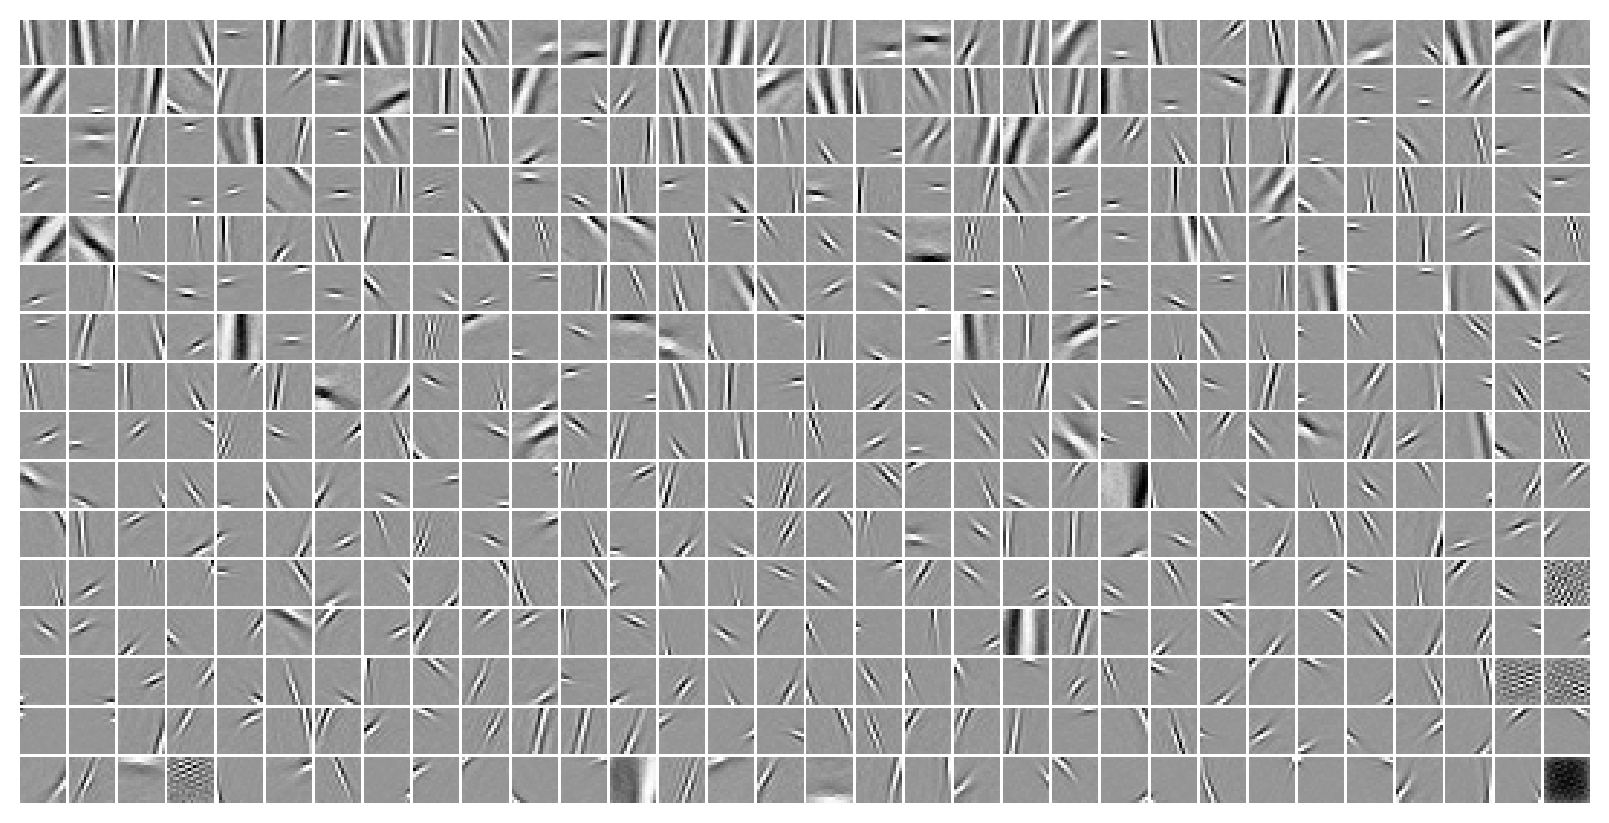

gaussian

100%|███████████████████████████████████| 3/3 [00:06<00:00,  2.28s/it]


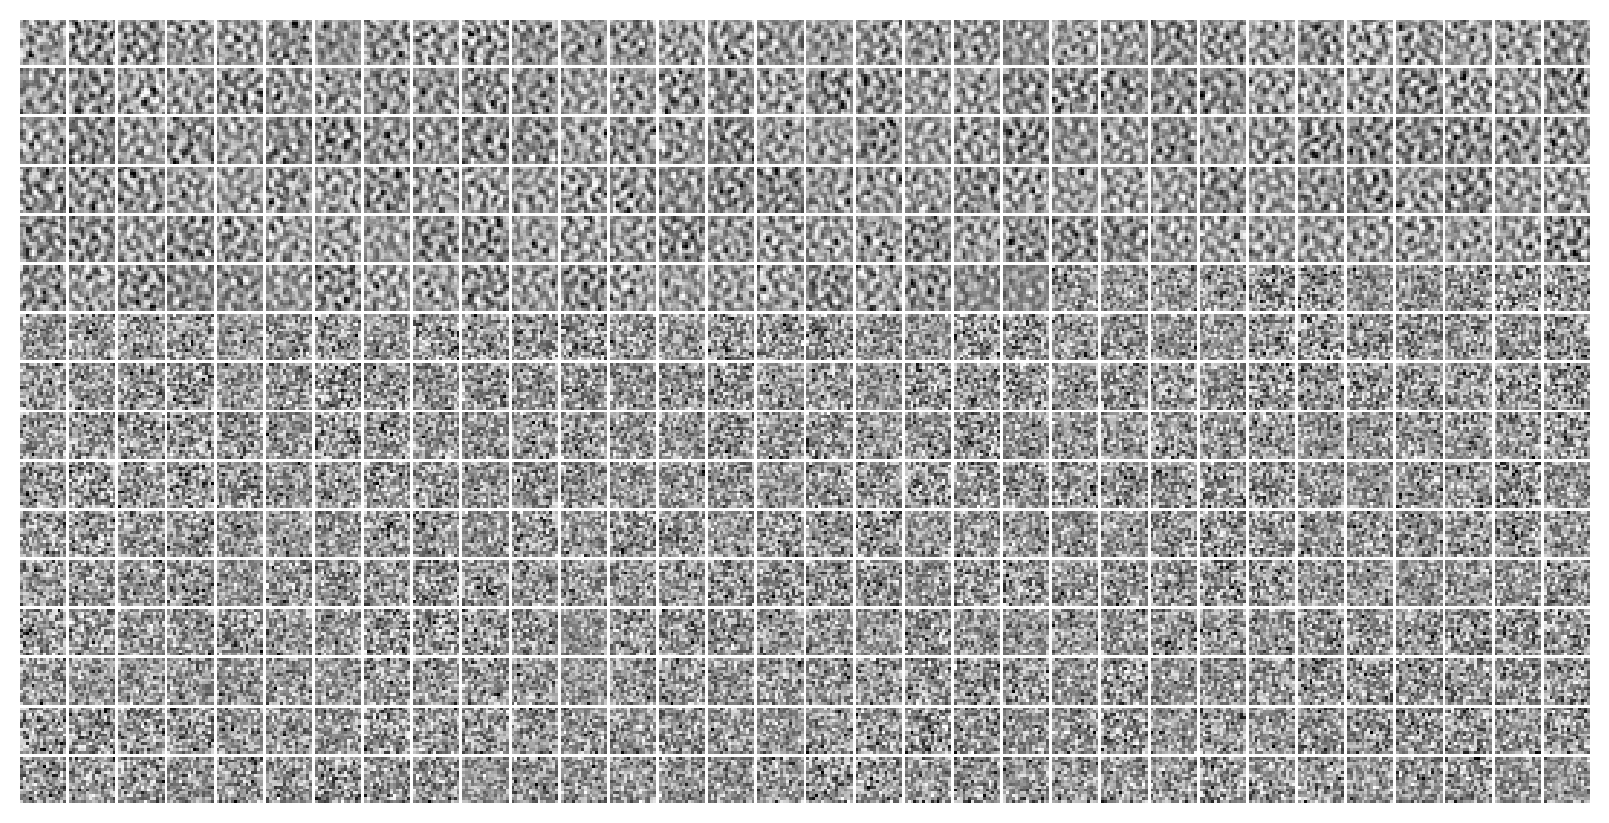

gaussian+relu

100%|███████████████████████████████████| 3/3 [00:07<00:00,  2.46s/it]


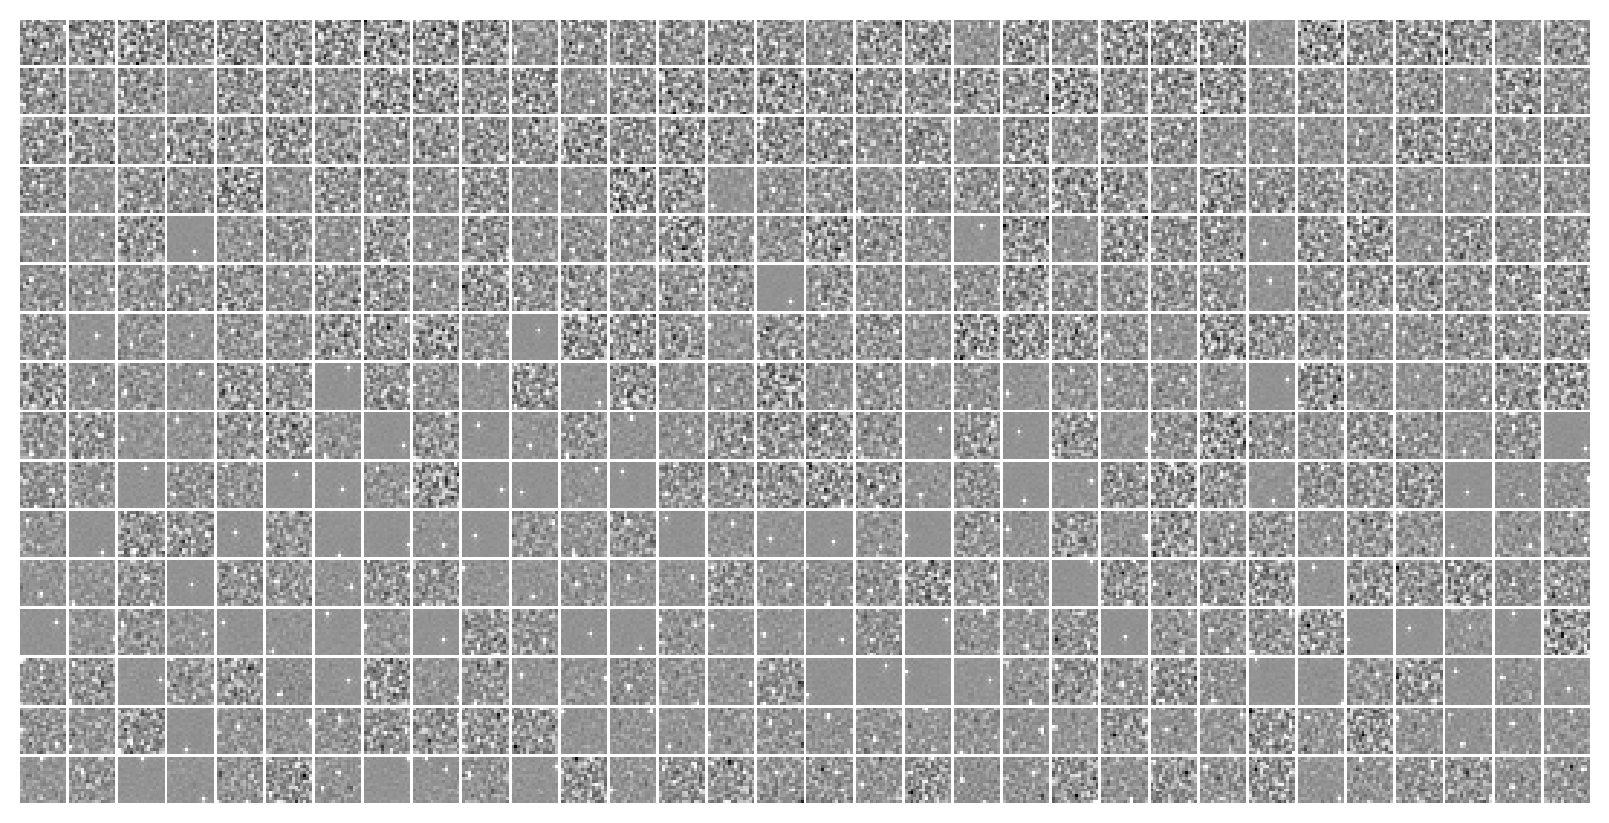

CPU times: user 22.6 s, sys: 1.82 s, total: 24.4 s
Wall time: 24.4 s


In [7]:
%%time

for name, tr in trainers.items():
    print(name)
    # extract features (we need posterior membrane potentials to order neurons)
    output = tr.xtract_ftr('vld', data_batch_sz=9_000, n_data_batches=-1)
    # final membrane potentials averaged over the entire test set
    u_final = output['state'][:, -1].mean(0)
    # order neurons
    order = np.argsort(u_final)
    # plot
    fig, _ = tr.model.show(order=order, method='abs-max')

### Demo: Trainer.xtract_ftr()

In [8]:
%%time

r2_all = {}
portion_zeros_all = {}

for name, tr in trainers.items():
    print(name)
    # extract features
    output = tr.xtract_ftr(
        dl='vld',  # validation data
        t_total=1_000,  # this is just T_test
        data_batch_sz=9_000,  # faster this way
        n_data_batches=-1,  # means go over the whole dataset
    )
    # collect results
    r2_all[name] = output['r2']  # this is r2 across the entire T_test
    portion_zeros_all[name] = output['portion_zeros']  # also len = T_test

poisson

100%|███████████████████████████████████| 3/3 [00:09<00:00,  3.12s/it]


gaussian

100%|███████████████████████████████████| 3/3 [00:06<00:00,  2.31s/it]


gaussian+relu

100%|███████████████████████████████████| 3/3 [00:07<00:00,  2.40s/it]

CPU times: user 22.2 s, sys: 1.32 s, total: 23.5 s
Wall time: 23.5 s


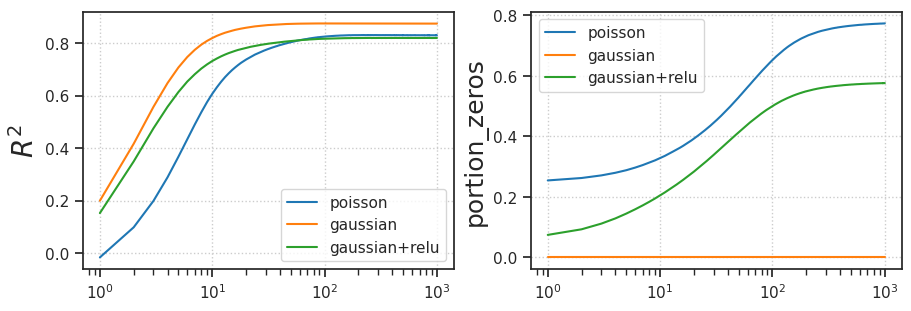

In [9]:
fig, axes = create_figure(1, 2, (9, 3))

for i, (name, r2) in enumerate(r2_all.items()):
    axes[0].plot(range(1, len(r2) + 1), r2, label=name, color=f'C{i}')
    axes[1].plot(range(1, len(r2) + 1), portion_zeros_all[name], label=name, color=f'C{i}')

for ax in axes.flat:
    ax.set(xscale='log')
    ax.legend()
    ax.grid()
    
axes[0].set_ylabel(r"$R^2$", fontsize=20)
axes[1].set_ylabel('portion_zeros', fontsize=18)

plt.show()

## Amortized Models

These are the amortized VAE models from [Poisson Variational Autoencoder
](https://openreview.net/forum?id=ektPEcqGLb) paper.

- Code: https://github.com/hadivafaii/PoissonVAE

**Important:** restart kernel and start fresh to avoid code conflict

In [1]:
import sys
sys.path.insert(0, "/home/hadi/Dropbox/git/PoissonVAE")

from utils.plotting import *
from base.utils_model import load_model_lite

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
set_style()

# root: where model checkpoints are saved at
root = 'Dropbox/git/IterativeVAE'  # base directory for the project (update to match yours)
root = add_home(f"{root}/checkpoints/")  # contains model checkpoints

# choose device
device_idx = 0
device = f'cuda:{device_idx}'

In [2]:
models2load = {
    'poisson': 'poisson-<conv+b|lin>-vH16-b-1_k-512',
    'gaussian': 'gaussian-<conv+b|lin>-vH16-b-1_k-512',
    'gaussian+relu': 'gaussian+relu-<conv+b|lin>-vH16-b-1_k-512',
}

In [3]:
trainers = {}
for model_name, f in models2load.items():
    # load trainer object (with model: tr.model)
    tr = load_model_lite(pjoin(root, f), device=device, verbose=True)[0]
    trainers[model_name] = tr


# params: 1.4 M

# params: 1.5 M

# params: 1.5 M


In [4]:
print(trainers['poisson'].model)

PoissonVAE(
  (mse): MSELoss()
  (stem): Conv2D(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc): Sequential(
    (0): Cell(
      (skip): Identity()
      (ops): ModuleList(
        (0-1): 2 x ConvLayer(
          (act_fn): SiLU()
          (conv): Conv2D(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
      (se): SELayer(
        (fc): Sequential(
          (0): Linear(in_features=32, out_features=4, bias=True)
          (1): ReLU(inplace=True)
          (2): Linear(in_features=4, out_features=32, bias=True)
          (3): Sigmoid()
        )
      )
    )
    (1): Cell(
      (skip): FactorizedReduce(
        (swish): SiLU()
        (ops): ModuleList(
          (0-3): 4 x Conv2D(32, 16, kernel_size=(1, 1), stride=(2, 2))
        )
      )
      (ops): ModuleList(
        (0): ConvLayer(
          (act_fn): SiLU()
          (conv): Conv2D(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        )
        (1): ConvLayer(
        

### Plot dictionary $\Phi$

poisson


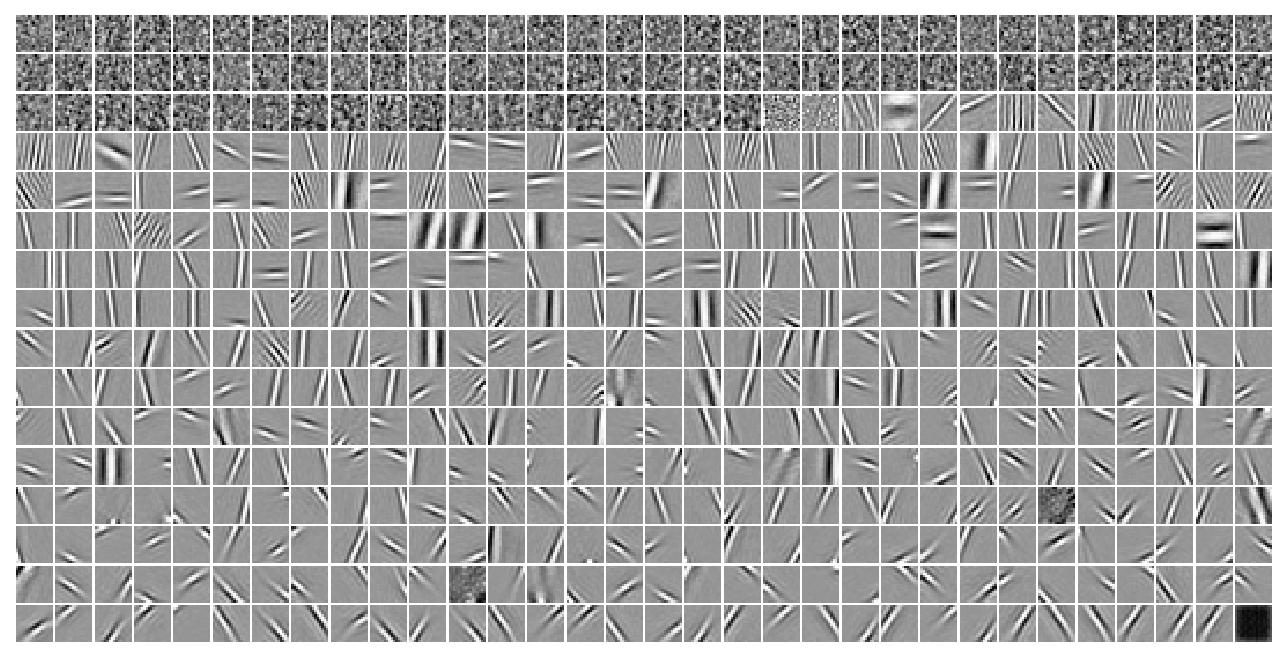

gaussian


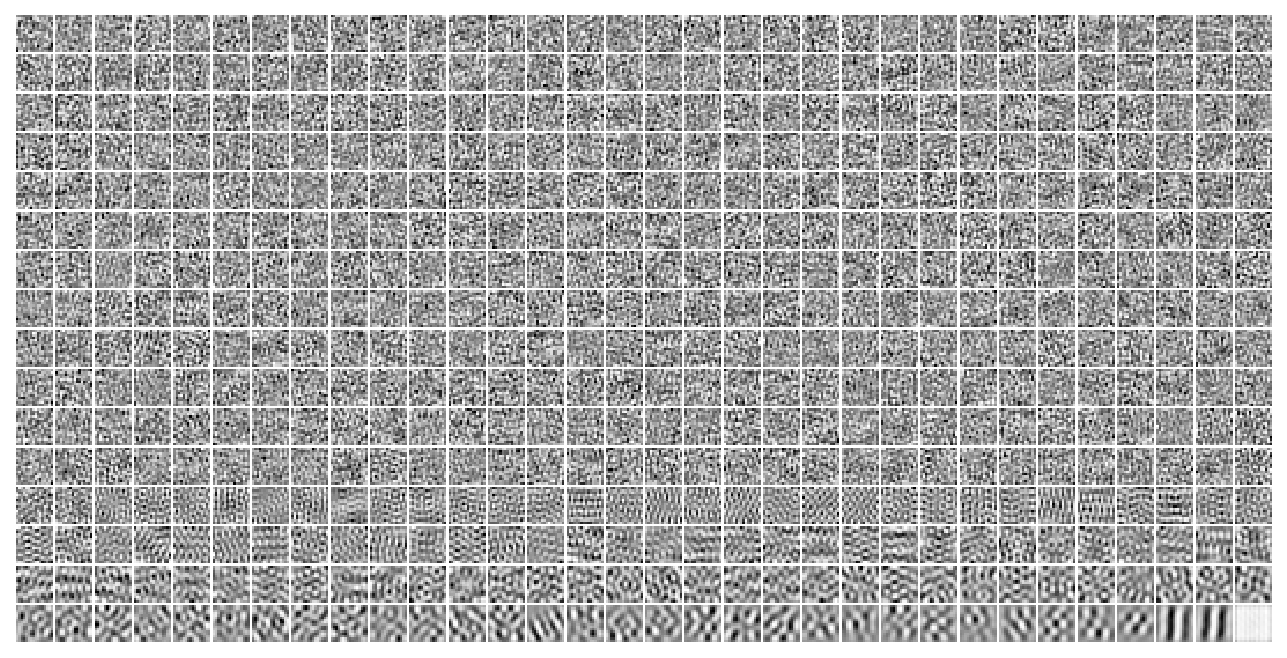

gaussian+relu


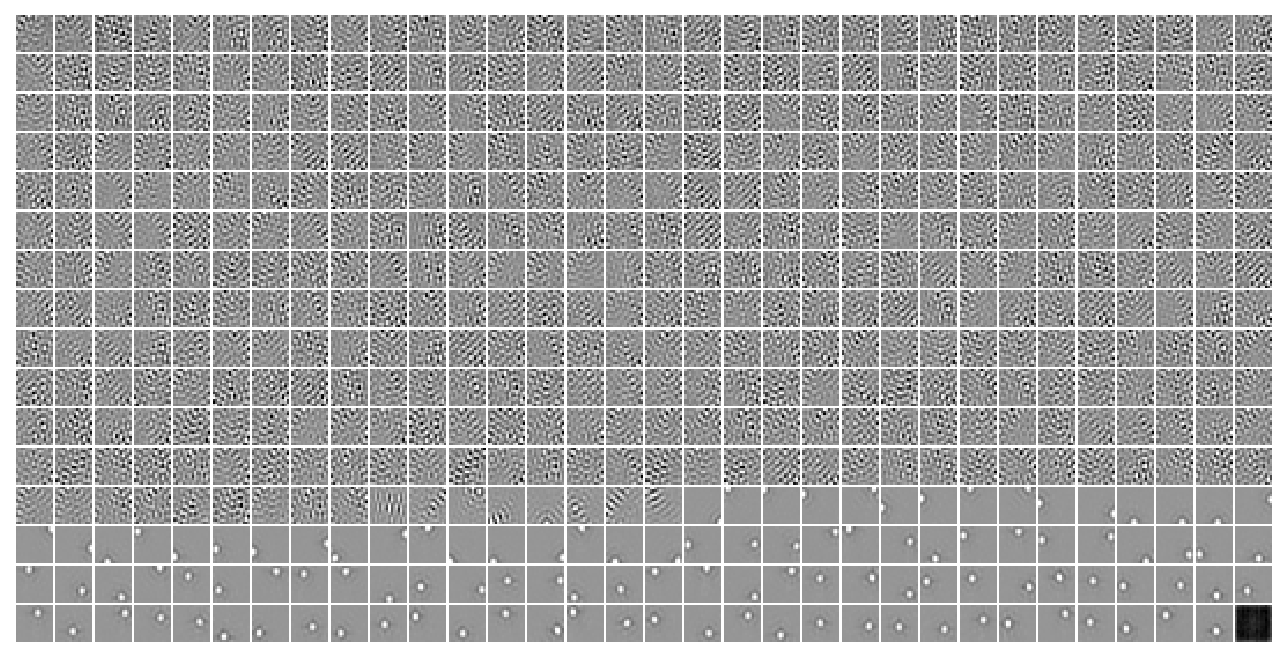

CPU times: user 1.22 s, sys: 349 ms, total: 1.57 s
Wall time: 1.56 s


In [5]:
%%time

for name, tr in trainers.items():
    print(name)
    # get kl loss (used to order neurons)
    data, loss, etc = tr.validate()
    # plot
    fig, _ = tr.model.show(
        order=np.argsort(loss['kl_diag']),
        method='abs-max',
        cmap='Greys_r',
    )

### Demo: Trainer.validate()

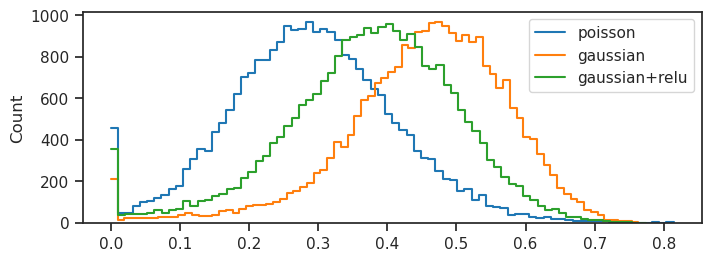

CPU times: user 924 ms, sys: 105 ms, total: 1.03 s
Wall time: 1.03 s


In [6]:
%%time

fig, ax = create_figure(1, 1, (7, 2.5))


r2_all = {}
portion_zeros_all = {}

for i, (name, tr) in enumerate(trainers.items()):

    data, loss, etc = tr.validate()
    
    # collect results
    r2 = loss['r2']
    r2[r2 < 0] = 0.0
    r2_all[name] = r2.mean()
    portion_zeros_all[name] = (data['z'] == 0).mean()

    sns.histplot(r2, label=name, color=f"C{i}", element='step', fill=False, ax=ax)

plt.legend()
plt.show()

In [7]:
print(f"r2:\n{r2_all}\n\nportion_zeros:\n{portion_zeros_all}")

r2:
{'poisson': 0.29059765, 'gaussian': 0.45494655, 'gaussian+relu': 0.37543514}

portion_zeros:
{'poisson': 0.9300409557698268, 'gaussian': 0.0, 'gaussian+relu': 0.49955468053833635}
